# Malaria Classification Task (Infected or UnInfected)

## Dataset Description

In [1]:
# Colored Picture usually have 3 channels - Red, Blue and Green. Each pixel is made of a combination of these 3 channels. 
# So our tensor for a colored picture will be (H,W,3): 3 is for 3 channels. A gray scale image has only 1 channel, therefore we have (H,W,1)
# (Black = 0) --- (White = 255)
# After Normalization, (Black = 0) --- (White = 1)

In [1]:
%pip install --upgrade --force-reinstall "protobuf>=6.31.1,<7"
%pip install --upgrade --force-reinstall tensorflow-datasets
%pip install --upgrade numpy scipy scikit-learn

  Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.


  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached array_record-0.8.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.1 kB)
  Using cached dm_tree-0.1.10-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached etils-1.14.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached immutabledict-4.3.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached promise-2.3-py3-none-any.whl
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached psutil-7.2.2-cp36-abi3-manylinux2010_x86_64.manylinux_2_12_x86_64.manylinux_2_28_x86_64.whl.metadata (22 kB)
  Using cached pyarrow-24.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8

## Importing

In [25]:
import io
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore
import tensorflow_probability as tfp # type: ignore
import sklearn 
import datetime
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import cv2
import albumentations as A # type: ignore
import wandb

# MODELS
Model = tf.keras.Model

#LAYERS
Layer = tf.keras.layers.Layer # importing Layer Class to inherit from
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization
Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Dropout =  tf.keras.layers.Dropout
RandomRotation = tf.keras.layers.RandomRotation
RandomFlip = tf.keras.layers.RandomFlip
Resizing = tf.keras.layers.Resizing
Rescaling = tf.keras.layers.Rescaling

#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

# METRICS
BinaryAccuracy = tf.keras.metrics.BinaryAccuracy # For a Binary Classification Problem
FalsePositives = tf.keras.metrics.FalsePositives
FalseNegatives = tf.keras.metrics.FalseNegatives
TruePositives = tf.keras.metrics.TruePositives
TrueNegatives = tf.keras.metrics.TrueNegatives
Precision = tf.keras.metrics.Precision
Recall = tf.keras.metrics.Recall
AUC = tf.keras.metrics.AUC
binary_accuracy = tf.keras.metrics.binary_accuracy

# Callbacks
Callback = tf.keras.callbacks.Callback
CSVLogger = tf.keras.callbacks.CSVLogger
LearningRateScheduler = tf.keras.callbacks.LearningRateScheduler
ProgBarLogger = tf.keras.callbacks.ProgbarLogger
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint
ReduceLRonPlateau = tf.keras.callbacks.ReduceLROnPlateau

# Regularizer
L2 = tf.keras.regularizers.L2

# Distributions
Beta = tfp.distributions.Beta

# Hyperparameter Tuning
from tensorboard.plugins.hparams import api as hp
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint, WandbEvalCallback # type: ignore

## Loading the Dataset

In [3]:
dataset, dataset_info = tfds.load('malaria', with_info=True, as_supervised = True, shuffle_files=True, split=['train']) # tfds_load returns the dataset and dataset_info | 'with_info=True' gives the dataset_info
# as_supervised -> if True returns a dataset with a 2 tuple structure (input, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.4NBFPK_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [4]:
dataset # this is a list with 1 element, so only select dataset[0]
# dataset_info
# for data in dataset[0].take(2):
#     print(data)

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

### Creating the Train, Test, Validation Datasets

In [5]:
def splits(dataset, TRAIN_RATIO, VAL_RATIO, TEST_RATIO):
    DATASET_SIZE = len(dataset)

    # 1. Take the first 60% for training
    train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE)) 

    # 2. Skip that 60% to look at the remaining 40% pool
    remaining_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))

    # 3. Take the first 20% of the total size from the remaining pool
    val_dataset = remaining_dataset.take(int(VAL_RATIO * DATASET_SIZE)) 

    # 4. Skip past the validation data to get the 5% and leave out 15% of the data
    test_pool = remaining_dataset.skip(int(TEST_RATIO * DATASET_SIZE))
    test_dataset = test_pool.take(int(TEST_RATIO * DATASET_SIZE))

    return train_dataset, val_dataset, test_dataset

In [6]:
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.05
# dataset = tf.data.Dataset.range(10)
train_dataset, val_dataset, test_dataset = splits(dataset[0], TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
# print('Train Dataset\n', list(train_dataset.take(1).as_numpy_iterator()),'Val Dataset\n', list(val_dataset.take(1).as_numpy_iterator()),'Test Dataset\n', list(test_dataset.take(1).as_numpy_iterator()))

In [ ]:
for image, label in train_dataset.take(16):
    print("Image Matrix Shape:", image.shape) 
    print("Label Value:", label.numpy())

# Wandb Install and Login and Initialization and Configuration

In [ ]:
# !wandb login
# wandb.init() - creates a run
# wandb.finish() - finish the run

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 


Aborted!
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1575, in _shutdown
    def _shutdown():
    
KeyboardInterrupt: 


In [29]:
# wandb.init(project="Malaria-Detection", entity='uhh-ni-university-of-alberta')
wandb.init(project="Malaria-Detection", entity='uhh-ni-university-of-alberta', sync_tensorboard=True)

In [ ]:
# wandb.run

In [8]:
wandb.config = {
    'LEARNING_RATE':0.001,
    'EPOCHS': 100,
    'BATCH_SIZE': 128,
    "IM_SIZE": 224,
    "REGULARIZATION_RATE": 0.0,
    "DROPOUT_RATE": 0.0,
    "N_FILTERS": 6,
    "KERNEL_SIZE": 3,
    "N_STRIDES": 1,
    "POOL_SIZE": 2,
    "N_DENSE_1": 128,
    "N_DENSE_2": 32,
}

# Data Visualization

In [ ]:
for i, (image, label) in enumerate(train_dataset.take(16)): # when using .take(), it goes from 1 - 16, hence the 'i+1'
    ax = plt.subplot(4,4, i+1) #(4,4) because we have 16 images
    plt.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
    plt.axis('off')

In [ ]:
dataset_info.features['label'].int2str(0) # our label of 0 means that it is parasitized

In [ ]:
dataset_info.features['label'].int2str(1) # our label of 1 means that it is uninfected

# Data PreProcessing


## Standardization / Normalization and Resizing

In [9]:
IM_SIZE = 224

In [10]:
# Image Resizing: Converting each image to 224,224 resolution
@tf.function # this function is changed to GRAPH MODE
def resize_rescale(image, label):
    return tf.image.resize(image,(IM_SIZE, IM_SIZE))/255.0, label
# We are dividing by 255 to rescale

In [ ]:
# Augment via tf.keras.layers resizing and rescaling
resize_rescale_layers = tf.keras.Sequential([
    Resizing(IM_SIZE, IM_SIZE), # [0.25 * 360, 0.2501 * 360], to keep the rotation to 90 degrees
    Rescaling(1.0/255),
])

## Data Augmentation

In [ ]:
def visualize(original, augmented):
    plt.subplot(1,2,1) ## Make a 1 row and 2 column plot and select the 1st position
    plt.imshow(original)

    plt.subplot(1,2,2)
    plt.imshow(augmented)

In [ ]:
original_image, label = next(iter(train_dataset))
augmented_image = tf.image.random_saturation(original_image, lower = 2, upper = 10)
visualize(original_image, augmented_image)

In [ ]:
augmented_image = tf.image.central_crop(original_image, central_fraction = 0.8) # we get the central part
visualize(original_image, augmented_image)

In [ ]:
# Why to not use saturation for this dataset
for i, (image, label) in enumerate(test_dataset.take(2)):
    plt.subplot(1,4,2*i+1)
    plt.imshow(image)

    plt.subplot(1,4,2*i+2)
    plt.imshow(tf.image.adjust_saturation(image, 0.8))
    plt.title(dataset_info.features['label'].int2str(label))
    plt.axis('off')

In [ ]:
# Augment via tf.image
# This method randomly picks which augmentation to do
@tf.function
def augment(image, label):

    image, label = resize_rescale(image, label)
    image = tf.image.rot90(image, k = tf.random.uniform(shape=[], minval=0, maxval=2, dtype=tf.int32))
    # image = tf.image.adjust_saturation(image, saturation_factor=0.3)
    # image = tf.image.stateless_random_saturation(image, 0.3, 0.5) 
    # # No point of adjusting contrast/saturation in our 
    # dataset becasue it makes it harder to differentiate between parasatized and non-parasatized cells
    image = tf.image.statless_random_flip_left_right(image)

    return image, label

In [ ]:
for image, label in train_dataset.take(1):
    print(image, label)
# Image is resized

In [ ]:
class Rot90(Layer):
    def __init__(self):
        super().__init__()
    
    @tf.function
    def call(self, image):
        return tf.image.rot90(image, k = tf.random.uniform(shape=[], minval=0, maxval=2, dtype=tf.int32))

In [ ]:
# Augment via tf.keras.layers
augment_layers = tf.keras.Sequential([
    Rot90(), # [0.25 * 360, 0.2501 * 360], to keep the rotation to 90 degrees
    RandomFlip(mode='horiontal',)
])
def augment_layer(image, label):
    image, label = resize_rescale(image, label)
    return augment_layers(image, training = True), label

## Mixup Data Augmentation

### Mixup Data Augmentation Demonstration

In [ ]:
lamda = tfp.distributions.Beta(0.2,0.2)
lamda = lamda.sample(1)[0]

image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE)) # Upload pictures to Colab GPU to run this
image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))

# image_1, label_1 = resize_rescale(cv2.imread('cat.jpg'), label=0)
# image_2, label_2 = resize_rescale(cv2.imread('dog.jpg'), label=1)

label_1 = 0
label_2 = 1

image = lamda * image_1 + (1-lamda) * image_2
label = lamda * tf.cast(label_1, dtype = tf.float32) + (1-lamda) * tf.cast(label_2, dtype = tf.float32)
print(image_1.shape)
print(image_2.shape)
print(lamda)
print(image_1.shape, label)
plt.axis('off')
plt.imshow(image/255,) # IMPORTANT to NORMALIZE it. Divide by 255

In [ ]:
train_dataset_1 = train_dataset.shuffle(buffer_size = 8, reshuffle_each_iteration=True).map(resize_rescale)
train_dataset_2 = train_dataset.shuffle(buffer_size = 8, reshuffle_each_iteration=True).map(resize_rescale)

mixed_dataset = tf.data.Dataset.zip(train_dataset_1, train_dataset_2)

In [ ]:
def box(lamda):
    
    r_x = tf.cast(tfp.distributions.Uniform(low=0 , high=IM_SIZE).sample(1)[0], dtype = tf.int32)
    r_y = tf.cast(tfp.distributions.Uniform(low=0 , high=IM_SIZE).sample(1)[0], dtype = tf.int32)


    r_w = tf.cast(IM_SIZE * tf.math.sqrt(1-lamda), dtype = tf.int32)
    r_h = tf.cast(IM_SIZE * tf.math.sqrt(1-lamda), dtype= tf.int32)

    # To get the top-left corner point
    r_x = tf.clip_by_value(r_x - r_w//2, 0, IM_SIZE) # 'tf.clip_by_value' - So the boxes are limited to the image - 13:23:50
    r_y = tf.clip_by_value(r_y - r_h//2, 0, IM_SIZE)

    # To get the bottom right point
    x_b_r = tf.clip_by_value(r_x + r_w//2, 0, IM_SIZE) # x bottom right
    y_b_r = tf.clip_by_value(r_y + r_h//2, 0, IM_SIZE)

    # Calculations done incase the box was out of bounds of the image
    r_w = x_b_r - r_x

    if(r_w == 0):
        r_w = 1

    r_h = y_b_r - r_y

    if(r_h == 0):
        r_h = 1

    return r_y, r_x, r_h, r_w

In [ ]:
# def mixup_trial(train_dataset_1, train_dataset_2):
#     (image_1, label_1), (image_2, label_2) = train_dataset_1, train_dataset_2
    
#     # image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE)) # Upload pictures to Colab GPU to run this
#     # image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))

#     lamda = tfp.distributions.Beta(0.2,0.2)
#     lamda = lamda.sample(1)[0]
#     # print(lamda.sample(1)[0].numpy()) # but we will work with tensors so no need to include .numpy()

#     label_1 = 0
#     label_2 = 1

#     image = lamda * image_1 + (1-lamda) * image_2
#     label = lamda * tf.cast(label_1, dtype = tf.float32) + (1-lamda) * tf.cast(label_2, dtype = tf.float32)
#     return image, label


# Can do this way as well
# image_1, label = resize_rescale(image_1, label=0)
# image_2, label = resize_rescale(image_2, label=1)
# print(image_1.shape)
# print(image_2.shape)
# print(lamda)
# print(image.shape, label)
# plt.imshow(image/255) # IMPORTANT to NORMALIZE it. Divide by 255


In [ ]:
# Cutmix Augmentation is NOT very helpful for the Malaria Diagnosis Dataset
def cutmix(train_dataset_1, train_dataset_2):
    (image_1, label_1), (image_2, label_2) = train_dataset_1, train_dataset_2

    lamda = tfp.distributions.Beta(0.2,0.2)
    lamda = lamda.sample(1)[0]

    r_y, r_x, r_h, r_w = box(lamda)


    
    crop_2 = tf.image.crop_to_bounding_box(image_2 ,r_y, r_x, r_h, r_w)
    pad_2 = tf.image.pad_to_bounding_box(crop_2,r_y, r_x, IM_SIZE, IM_SIZE)

    crop_1 = tf.image.crop_to_bounding_box(image_1, r_y, r_x, r_h, r_w)
    pad_1 = tf.image.pad_to_bounding_box(crop_1, r_y, r_x, IM_SIZE, IM_SIZE)

    image = image_1 - pad_1 + pad_2

    lamda = tf.cast(1 - (r_w*r_h)/(IM_SIZE*IM_SIZE), dtype=tf.float32)
    label = lamda*tf.cast(label_1, dtype=tf.float32) + (1-lamda)*tf.cast(label_2, dtype=tf.float32)
    
    return image, label

## Cutmix Augmentation

### Cutmix Augmentation Demonstration

In [ ]:
plt.figure(figsize=(16,8))

plt.subplot(1,8,1)
image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE))
plt.axis('off')
plt.imshow(image_1)

plt.subplot(1,8,2)
image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))
plt.axis('off')
plt.imshow(image_2)

# Chopped Image Haha
plt.subplot(1,8,3)
crop = tf.image.crop_to_bounding_box(image_2 , 20, 60, 100, 98) # Zoomed In
plt.axis('off')
plt.imshow(crop)

# Image is stamped on a picture of 0's
plt.subplot(1,8,4)
padded = tf.image.pad_to_bounding_box(crop, 20, 100, IM_SIZE, IM_SIZE)
plt.axis('off')
plt.imshow(padded)

# Don't want this
plt.subplot(1,8,5)
plt.axis('off')
plt.imshow(padded + image_1)

plt.subplot(1,8,6)
crop_cat = tf.image.crop_to_bounding_box(image_1, 20, 100, 100, 98)
plt.axis('off')
plt.imshow(crop_cat)

plt.subplot(1,8,7)
image_5 = tf.image.pad_to_bounding_box(crop_cat, 20, 100, IM_SIZE, IM_SIZE)
plt.axis('off')
plt.imshow(image_1 - image_5)

# Add image to the HOLE
plt.subplot(1,8,8)
plt.axis('off')
plt.imshow(image_1 - image_5 + padded)


# Shuffling the dataset

In [11]:
BATCH_SIZE = 32

In [12]:
train_dataset = (train_dataset
                .shuffle(buffer_size=8, reshuffle_each_iteration=True)
                # .map(mixup) # include the mapping AFTER shuffling
                .map(resize_rescale)
                .batch(BATCH_SIZE)
               #  .prefetch(tf.data.AUTOTUNE)
                )

tf.Tensor([0 1 1 1 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 0 1], shape=(32,), dtype=int64)


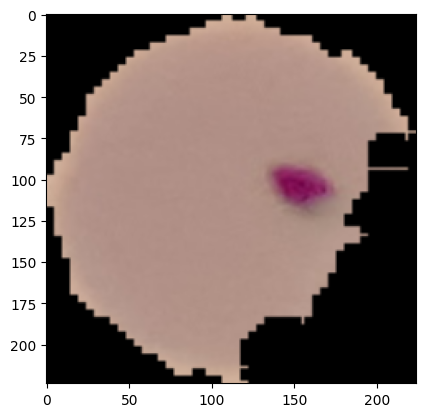

In [ ]:
# We can see the patches on the image using the cutmix Augmentation
original_image, label = next(iter(train_dataset))
print(label)
plt.imshow(original_image[0])

In [13]:
# Don't reshuffle val_dataset, so no 'reshuffle_each_iteration=True', don't augment the val and test dataset
val_dataset = (val_dataset
               .shuffle(buffer_size=8)
               .map(resize_rescale)
               # .map(cutmix)
               .batch(BATCH_SIZE)
               # .prefetch(tf.data.AUTOTUNE)
               )

# Don't do anything with the test_dataset
test_dataset = test_dataset.map(resize_rescale)

In [14]:
print(train_dataset,'\n', val_dataset, '\n', test_dataset)
print(f'Length of training Dataset: {len(train_dataset) * 32}')
print(f'Length of Validation Dataset: {len(val_dataset) * 32}')
print(f'Length of Test Dataset: {len(test_dataset)}')

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> 
 <_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> 
 <_MapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Length of training Dataset: 16544
Length of Validation Dataset: 5536
Length of Test Dataset: 1377


# Augmentation with Albumentations Library

[Albumentations Documentation](https://albumentations.ai/docs/reference/supported-targets-by-transform/)

In [ ]:
# Image Augmentation
transforms = A.Compose([

    A.Resize(IM_SIZE, IM_SIZE),

    # For either a horizontal or a Vertical flip, p signifies if the oneof is going to be applied or not
    A.OneOf([A.HorizontalFlip(), A.VerticalFlip()], p= 0.3),

    A.RandomRotate90(),
    A.RandomGridShuffle (grid=(3, 3), always_apply=False, p=0.5),

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, brightness_by_max=True, p=0.5),

    A.CoarseDropout( num_holes_range=(1, 8), hole_height_range=(8, 32), hole_width_range=(8, 32), fill=1, p=0.7), # to make holes
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), always_apply=False, p=0.5)
])

/tmp/ipykernel_1689/3159004603.py:10: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomGridShuffle
  A.RandomGridShuffle (grid=(3, 3), always_apply=False, p=0.5),
/tmp/ipykernel_1689/3159004603.py:15: UserWarning: Argument(s) 'always_apply' are not valid for transform Sharpen
  A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), always_apply=False, p=0.5)


In [ ]:
def aug_albument(image):
    data = {"image":image}
    image = transforms(**data)
    image = image["image"]
    image = tf.cast(image/255., tf.float32)
    return image

In [ ]:
def process_data(image, label):
    aug_img = tf.numpy_function(func=aug_albument, inp=[image], Tout=tf.float32)
    aug_img.set_shape((IM_SIZE, IM_SIZE, 3))  
    return aug_img, label

In [ ]:
train_dataset = (train_dataset
                .shuffle(buffer_size=8, reshuffle_each_iteration=True)
                # .map(mixup) # include the mapping AFTER shuffling
                .map(process_data)
                .batch(BATCH_SIZE)
               #  .prefetch(tf.data.AUTOTUNE)
                )

In [ ]:
train_dataset

In [ ]:
im, lbl = next(iter(train_dataset))
plt.imshow(im[0])

In [ ]:
plt.figure(figsize=(15,10))

for i in range(1,32):
    plt.subplot(8,4,i)
    plt.imshow(im[i])
    plt.axis('off')

# Hyperparameter Tuning

## Grid Search HyperParameter Tuning

In [ ]:
# The set of Hyperparameters that we want to try out
HP_NUM_UNITS_1 = hp.HParam('num_units_1', hp.Discrete([16,32,64,128]))
HP_NUM_UNITS_2 = hp.HParam('num_units_2', hp.Discrete([16,32,64,128]))
HP_DROPOUT = hp.HParam('dropout_rate', hp.Discrete([0.1, 0.2, 0.3]))
HP_REGULARIZATION_RATE = hp.HParam('regularization_rate', hp.Discrete([0.001, 0.01, 0.1]))
HP_LEARNING_RATE = hp.HParam('learning_rate', hp.Discrete([1e-4, 1e-3]))

In [ ]:
IM_SIZE = 224
def model_tune(hparams):   
    lenet_model = tf.keras.Sequential([
                                    InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                    
                                    Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', kernel_regularizer=L2(hparams[HP_REGULARIZATION_RATE])),
                                    BatchNormalization(), 
                                    MaxPool2D(pool_size= 2, strides=2),
                                    Dropout(rate=hparams[HP_DROPOUT]),

                                    Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu',kernel_regularizer=L2(hparams[HP_REGULARIZATION_RATE])),
                                    BatchNormalization(), 
                                    MaxPool2D(pool_size= 2, strides=2),

                                    Flatten(), 

                                    Dense(hparams[HP_NUM_UNITS_1], activation='relu', kernel_regularizer=L2(hparams[HP_REGULARIZATION_RATE])),
                                    BatchNormalization(),
                                    Dropout(rate=hparams[HP_DROPOUT]),

                                    Dense(hparams[HP_NUM_UNITS_2], activation='leaky_relu', kernel_regularizer=L2(hparams[HP_REGULARIZATION_RATE])),
                                    BatchNormalization(),

                                    Dense(1, activation='sigmoid')
                                    ])

    lenet_model.compile(optimizer= Adam(learning_rate = hparams[HP_LEARNING_RATE]), loss = 'bce', metrics = ['accuracy'],)
    lenet_model.fit(val_dataset, epochs = 1)
    _, accuracy = lenet_model.evaluate(val_dataset)
    return accuracy

In [ ]:
run_number = 0
for num_units_1 in HP_NUM_UNITS_1.domain.values:
    for num_units_2 in HP_NUM_UNITS_2.domain.values:
        for dropout_rate in HP_DROPOUT.domain.values:
            for regularization_rate in HP_REGULARIZATION_RATE.domain.values:
                for learning_rate in HP_LEARNING_RATE.domain.values:

                    hparams = {
                        HP_NUM_UNITS_1: num_units_1,
                        HP_NUM_UNITS_2: num_units_2,
                        HP_DROPOUT: dropout_rate,
                        HP_REGULARIZATION_RATE: regularization_rate,
                        HP_LEARNING_RATE: learning_rate,
                        }
                    
                    file_writer = tf.summary.create_file_writer('logs/' + str(run_number))
                    with file_writer.as_default():
                        hp.hparams(hparams)
                        accuracy = model_tune(hparams)
                        tf.summary.scalar('accuracy', accuracy, step = 0)
                    print("For the run {}, hparams num_units_1:{}, num_units_2:{}, dropout: {}, regularization_rate:{}, learning_rate:{}".format(run_number, hparams[HP_NUM_UNITS_1], 
                    hparams[HP_NUM_UNITS_2],hparams[HP_DROPOUT], hparams[HP_REGULARIZATION_RATE], hparams[HP_LEARNING_RATE]))
                    run_number += 1

173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.5995 - loss: 0.7759
173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6413 - loss: 0.7111
For the run 0, hparams num_units_1:16, num_units_2:16, dropout: 0.1, regularization_rate:0.001, learning_rate:0.0001
173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6939 - loss: 0.6816
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.5034 - loss: 0.9204
For the run 1, hparams num_units_1:16, num_units_2:16, dropout: 0.1, regularization_rate:0.001, learning_rate:0.001
173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.5839 - loss: 1.2620
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.5197 - loss: 1.2347
For the run 2, hparams num_units_1:16, num_units_2:16, dropout: 0.1, regularization_rate:0.01, learning_rate:0.0001
173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6509 - loss: 1.2319
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.4990 - loss: 1.2931
For the run 3, hparams num_units_1:

: 

: 

: 

## Random Search HyperParameter Tuning

# HyperParameter Tuning with Wandb

In [30]:
sweep_config = {
  "name" : "Malaria-Prediction-Sweep",
  "method" : "random",
  "metric": {
      "name" : "accuracy",
      "goal" : "maximize",
  },
  "parameters" : {
    
    "IM_SIZE": {
        "value" : 224,
    },

    "N_EPOCHS": {
        "value" : 1,
    },
    
    "KERNEL_SIZE": {
        "value" : 3,
    },

    "N_STRIDES": {
        "value" : 1,
    },

    "POOL_SIZE": {
        "value" : 224,
    },
  
    "N_FILTERS" : {
        "value" : 6,
    },
      
    "N_DENSE_1" : {
      "values" : [16, 32, 64, 128]
    },

    "N_DENSE_2" : {
      "values" : [16, 32, 64, 128]
    },

    "DROPOUT_RATE":{
      "min": 0.1,
      "max": 0.4
    },

    "REGULARIZATION_RATE" :{
      "distribution": "uniform",
      "min": 0.001,
      "max": 0.1
    },

    "LEARNING_RATE" :{
      "distribution": "uniform",
      "min": 1e-4,
      "max": 1e-2
    }
  },
}

sweep_id = wandb.sweep(sweep_config)

Create sweep with ID: 3poek7f0
Sweep URL: https://wandb.ai/uhh-ni-university-of-alberta/uncategorized/sweeps/3poek7f0


In [31]:
IM_SIZE = 224
def model_tune(config):
  lenet_model = tf.keras.Sequential([
    InputLayer(input_shape = (224, 224, 3)),

    Conv2D(filters = 6 , kernel_size = 3, strides = 1 , padding='valid',
          activation = 'relu',kernel_regularizer = L2(config['REGULARIZATION_RATE'])),
    BatchNormalization(),
    MaxPool2D (pool_size = 1, strides= config['N_STRIDES']*2),
    Dropout(rate = config['DROPOUT_RATE'] ),

    Conv2D(filters = 16, kernel_size = 3, strides = 1, padding='valid',
          activation = 'relu', kernel_regularizer = L2(config['REGULARIZATION_RATE'])),
    BatchNormalization(),
    MaxPool2D (pool_size = 1, strides= 2),

    Flatten(),
    
    Dense( config['N_DENSE_1'], activation = "relu", kernel_regularizer = L2(config['REGULARIZATION_RATE'])),
    BatchNormalization(),
    Dropout(rate = config['DROPOUT_RATE']),
    
    Dense( config['N_DENSE_2'], activation = "relu", kernel_regularizer = L2(config['REGULARIZATION_RATE'])),
    BatchNormalization(),

    Dense(1, activation = "sigmoid"),

  ])


  return lenet_model

In [32]:
def train():
    with wandb.init(project="Malaria-Detection", entity="uhh-ni-university-of-alberta") as run:
        config = wandb.config
        model = model_tune(config)
        model.compile(
              optimizer= Adam(
                  learning_rate = config['LEARNING_RATE']),
              loss='binary_crossentropy',
              metrics=['accuracy'],
              )
        model.fit(val_dataset, epochs=2, callbacks = [WandbMetricsLogger()])
        #wandb.log({"loss": loss, "epoch": epoch})

count = 5 # number of runs to execute
wandb.agent(sweep_id, function=train, count=count)
     

wandb: Agent Starting Run: 4i046853 with config:
wandb: 	DROPOUT_RATE: 0.31624667746127577
wandb: 	IM_SIZE: 224
wandb: 	KERNEL_SIZE: 3
wandb: 	LEARNING_RATE: 0.007683034770581312
wandb: 	N_DENSE_1: 128
wandb: 	N_DENSE_2: 16
wandb: 	N_EPOCHS: 1
wandb: 	N_FILTERS: 6
wandb: 	N_STRIDES: 1
wandb: 	POOL_SIZE: 224
wandb: 	REGULARIZATION_RATE: 0.036728908277089925
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.6215 - loss: 9.9285
Epoch 2/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6336 - loss: 3.2655


epoch/accuracy,▁█
epoch/epoch,▁█
epoch/learning_rate,▁▁
epoch/loss,█▁
epoch/accuracy,0.63364
epoch/epoch,1
epoch/learning_rate,0.00768
epoch/loss,3.26552


wandb: Agent Starting Run: psj6ogxf with config:
wandb: 	DROPOUT_RATE: 0.17279603547868633
wandb: 	IM_SIZE: 224
wandb: 	KERNEL_SIZE: 3
wandb: 	LEARNING_RATE: 0.007681370267119246
wandb: 	N_DENSE_1: 32
wandb: 	N_DENSE_2: 32
wandb: 	N_EPOCHS: 1
wandb: 	N_FILTERS: 6
wandb: 	N_STRIDES: 1
wandb: 	POOL_SIZE: 224
wandb: 	REGULARIZATION_RATE: 0.044053858407265535
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.6004 - loss: 5.6937
Epoch 2/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.6218 - loss: 1.7260


...

wandb: Agent Starting Run: 8vrwhz3n with config:
wandb: 	DROPOUT_RATE: 0.34225248369105765
wandb: 	IM_SIZE: 224
wandb: 	KERNEL_SIZE: 3
wandb: 	LEARNING_RATE: 0.006993053023972853
wandb: 	N_DENSE_1: 16
wandb: 	N_DENSE_2: 32
wandb: 	N_EPOCHS: 1
wandb: 	N_FILTERS: 6
wandb: 	N_STRIDES: 1
wandb: 	POOL_SIZE: 224
wandb: 	REGULARIZATION_RATE: 0.08913383790228677
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.6001 - loss: 4.6713
Epoch 2/2
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6062 - loss: 1.8662


epoch/accuracy,▁█
epoch/epoch,▁█
epoch/learning_rate,▁▁
epoch/loss,█▁
epoch/accuracy,0.60624
epoch/epoch,1
epoch/learning_rate,0.00699
epoch/loss,1.86618


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fc17c14ab40>> (for post_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

# Model Creation

### Sequential API

In [15]:
# LeNet Architecture
# The Models weights, are the filters that we learn
# dropout_rate = 0.3
# regularization_rate = 0.01
CONFIGURATION = wandb.config
IM_SIZE = CONFIGURATION['IM_SIZE']
DROPOUT_RATE = CONFIGURATION['DROPOUT_RATE']
REGULARIZATION_RATE = CONFIGURATION['REGULARIZATION_RATE']
N_FILTERS = CONFIGURATION['N_FILTERS']
KERNEL_SIZE = CONFIGURATION['KERNEL_SIZE']
POOL_SIZE = CONFIGURATION['POOL_SIZE']
N_STRIDES = CONFIGURATION['N_STRIDES']


lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                            
                            Conv2D(filters = N_FILTERS, kernel_size = KERNEL_SIZE, strides= N_STRIDES, padding='valid', activation='relu', kernel_regularizer=L2(REGULARIZATION_RATE)),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= POOL_SIZE, strides=2),
                            Dropout(rate=DROPOUT_RATE),

                            Conv2D(filters = N_FILTERS*2 + 4, kernel_size = KERNEL_SIZE, strides= N_STRIDES, padding='valid', activation='relu',kernel_regularizer=L2(REGULARIZATION_RATE)),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= POOL_SIZE, strides=2 * N_STRIDES),

                            Flatten(), 

                            Dense(CONFIGURATION["N_DENSE_1"], activation='relu', kernel_regularizer=L2(REGULARIZATION_RATE)),
                            BatchNormalization(),
                            Dropout(rate=DROPOUT_RATE),

                            Dense(CONFIGURATION["N_DENSE_2"], activation='leaky_relu', kernel_regularizer=L2(REGULARIZATION_RATE)),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ])
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,972,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,978,033 (22.80 MB)

 Trainable params: 5,977,669 (22.80 MB)

 Non-trainable params: 364 (1.42 KB)

## Functional API

In [ ]:
# PUTTING ALL THE FEATURE EXTRACTOR LAYER INTO 'feature_extractor_model'
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '1st Convolution Layer')(func_input)
x = BatchNormalization(name = '1st Normalization Layer')(x) 
x = MaxPool2D(pool_size= 2, strides=2, name = '1st Pooling Layer')(x)
x = Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '2nd Convolution Layer')(x)
x = BatchNormalization(name = '2nd Normalization Layer')(x)

output = MaxPool2D(pool_size= 2, strides=2, name = 'output')(x)

feature_extractor_model = Model(func_input, output, name = 'Feature_Extractor')
feature_extractor_model.summary()

## Adding the Feature Extractor Model to the Classification Layers

In [ ]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_extractor_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)


# Need to mention that 'lenet_model_func' is a MODEL with 'func_input' and 'func_output'
lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()


## Feature Extractor - Sequential Model

In [ ]:
feature_extractor_seq_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2)])

x = feature_extractor_seq_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()

In [ ]:
# tf.keras.utils.plot_model(lenet_model, to_file='model.png', show_shapes=True)

## Model SubClassing

In [ ]:
class FeatureExtractor(Layer): # FeatureExtractor inherits from Layer
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(FeatureExtractor, self).__init__() # This line reaches up to the parent Keras Layer class and boots up its internal initialization configuration.
        '''A native Keras layer has a ton of invisible, complex machinery required to track weight gradients and shape states.
           If you omit this line, your custom layer's setup will overwrite the core Keras setup, completely breaking the layer. Running super().__init__()
           ensures that Keras sets up its vital internal plumbing before you start adding your custom layers underneath it.'''
        


        # All the layers are being DEFINED here
        
        self.conv_1 = Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        # we are equating filters = filters because we don't want to mix up the argument values here and how it is defined in the documentation
        self.batch_1 = BatchNormalization()
        self.pool_1 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)

        self.conv_2 = Conv2D(filters = filters * 2, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        self.batch_2 = BatchNormalization()
        self.pool_2 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)


    def call(self, x, training = False): 
        x = self.conv_1(x)
        x = self.batch_1(x)
        x = self.pool_1(x)

        x = self.conv_2(x)
        x = self.batch_2(x)
        x = self.pool_2(x)

        return x
        

feature_sub_classed = FeatureExtractor(8, 3, 1, 'valid', 'relu', 2)

In [ ]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_sub_classed(func_input) 
# When you pass func_input into feature_sub_classed(...), 
# Keras automatically jumps inside your custom class and runs the 'call' method under the hood.

x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model: Feature Subclassing')
lenet_model_func.summary()

In [ ]:
# Adding the Classification layer to make the whole LeNet Model

class LenetModel(Model):
  def __init__(self):
    super(LenetModel, self).__init__()

    self.feature_extractor = FeatureExtractor(8, 3, 1, "valid", "relu", 2)

    self.flatten = Flatten()

    self.dense_1 = Dense(100, activation = "relu")
    self.batch_1 = BatchNormalization()

    self.dense_2 = Dense(10, activation = "relu")
    self.batch_2 = BatchNormalization()

    self.dense_3 = Dense(1, activation = "sigmoid") # parameter 1: number of output units
    
  def call(self, x, training = False):

    x = self.feature_extractor(x)
    x = self.flatten(x)
    x = self.dense_1(x)
    x = self.batch_1(x)
    x = self.dense_2(x)
    x = self.batch_2(x)
    x = self.dense_3(x)

    return x





# Final LeNet Model using Feature Extractor + Classification Layer 
lenet_sub_classed = LenetModel()
lenet_sub_classed(tf.zeros([1,224,224,3]))
lenet_sub_classed.summary()

## Custom Layers

In [ ]:
# Instead of relying on tf.keras.layers.Dense, we are manually implementing the foundational linear algebra equation of deep learning
class NeuralearnDense(Layer): # Making the custom DENSE Layer
    def __init__(self, output_units, activation):
        super(NeuralearnDense, self).__init__()
        self.output_units = output_units # gives the number of columns
        self.activation = activation
    
    def build(self, input_features_shape): #Important '9:19:05'                                     INPUT: (Batch Size, Features), W: (Features,1), Bias: (Batch Size,1)
        #                                                                                           So Y = INPUT * W + B for the Dense Layer
                                        #      number of rows        number of columns
                                        #            |                      |
                                        #            v                      v
        self.w = self.add_weight(shape = (input_features_shape[-1], self.output_units), initializer='random_normal', trainable=True) # NEED TO GET THE SHAPES RIGHT 
        # random normal weight initializer
        self.b = self.add_weight(shape = (self.output_units, ), initializer='random_normal', trainable=True)

    def call(self, input_features): # This handles the actual forward pass math whenever data flows through the layer.

        pre_output = tf.matmul(input_features, self.w) + self.b # IMPORTANT: THE FORMULA FOR THE DENSE LAYER

        if (self.activation == 'relu'):
            return tf.nn.relu(pre_output)
        elif (self.activation == 'sigmoid'):
            return tf.math.sigmoid(pre_output)
        else:
            pre_output

In [ ]:
# Using our custom DENSE LAYER
lenet_model_custom_dense = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            NeuralearnDense(100, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(10, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(1, activation='sigmoid')
                            ]) 

lenet_model_custom_dense.summary()

# Custom Loss Method

## Loss without Parameters

In [ ]:
# Binary Cross Entropy Loss
def custom_bce(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()
    return bce(y_true, y_pred) # use from_logits = True when the predictions are above 1 and lesser than 0.

## Loss with Parameters

In [ ]:
FACTOR = 1
def custom_bce(FACTOR):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.BinaryCrossentropy()
        return bce(y_true, y_pred) * FACTOR # use from_logits = True when the predictions are above 1 and lesser than 0.
    return loss

## Custom Loss Class

In [ ]:
FACTOR = 1
class CustomBCE(tf.keras.losses.Loss):
    def __init__(self, FACTOR):
        super(CustomBCE, self).__init__()
        self.FACTOR = FACTOR
    def call(self, y_true, y_pred):
        bce = tf.keras.losses.BinaryCrossentropy()
        return bce(y_true, y_pred) * self.FACTOR


# Custom Metrics

## Without Parameters

In [ ]:
def custom_accuracy(y_true, y_pred):
    return binary_accuracy(y_true, y_pred)

## With Parameters

In [ ]:
FACTOR_ACC = 1
def custom_accuracy_param(FACTOR_ACC):
    def metric(y_true, y_pred):
        return binary_accuracy(y_true, y_pred) * FACTOR_ACC # use from_logits = True when the predictions are above 1 and lesser than 0.
    return metric

## Custom Metrics Class

In [ ]:
class CustomAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name = 'Custom_Accuracy_haha', FACTOR = 1):
        super(CustomAccuracy, self).__init__()
        self.FACTOR = FACTOR
        self.accuracy = self.add_weight(name = name, initializer = 'zeros')
    
    def update_state(self, y_true, y_pred, sample_weight = None):
        y_true = tf.cast(y_true, dtype = tf.float32)
        output = binary_accuracy(y_true, y_pred) * self.FACTOR
        
        # output has a tensor like [[1.] [1.] [1.]....] 1 - correct prediction, 0 - wrong pediction. 
        # That is why we do tf.reduce_mean
        y_true = tf.cast(y_true, dtype = tf.float32)
        output = binary_accuracy(y_true, y_pred) * self.FACTOR
        self.accuracy.assign(tf.reduce_mean(output))
    
    def result(self):
        return self.accuracy

    def reset_states(self):
        self.accuracy.assign(0.)

# Graph Mode Vs Eager Mode

Adding '@tf.function' above the function changes the function to render in a graph mode.

Eg. 
    
    @tf.function
    def BigFunction():
        ...
        return None




If '@tf.function()' is called on the 'BigFunction' which has a 'SmallFunction' inside it, 
then we don't need to call @tf.function() on the 'SmallFunction', as it is redundant.

Eg. 
    
    @tf.function -> NOT NEEDED HERE
    def SmallFunction():
        ...
        return None
    

    @tf.function() -> This is enough
    def BigFunction():
        x = SmallFunction()
        ...
        return None

Use **'tf.print('Hello')'** when you want to print in the graph mode.


**'tf.config.run_functions_eagerly(True)'** to run functions EAGERLY.

14:18:30

# Metrics

In [17]:
# Precision, Recall and Accuracy etc.
metrics = [TruePositives(name='tp'), FalsePositives(name = 'fp'), TrueNegatives(name = 'tn'), FalseNegatives(name = 'fn'),
            BinaryAccuracy(name='accuracy'), Precision(name = 'precision'), Recall(name = 'recall'), AUC(name = 'auc')]

# Can include '[CustomAccuracy(FACTOR=1)]'

In [18]:
lenet_model.compile(optimizer= Adam(learning_rate = CONFIGURATION['LEARNING_RATE']), loss = 'bce', metrics = metrics,) 

# or could add metrics = [RootMeanSquaredError()], '[CustomAccuracy(FACTOR=1)]'
# Have graph mode and eager mode, run_eagerly = True
LABELS = ['Parasitized', 'Uninfected']

In [ ]:
# lenet_model_func.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = ['accuracy']) #metrics = [RootMeanSquaredError()]

# Model Training

## CallBacks

In [ ]:
# Callbacks are special tools that let you sneak a peek inside your neural network while it is actively training

### LogImagesCallback

In [ ]:
class LogImagesCallbackTensorBoard(Callback):
  def on_epoch_end(self, epoch, logs):
    labels = []
    inp = []

    for x,y in test_dataset.as_numpy_iterator():
      labels.append(y)
      inp.append(x)
    labels = np.array([i[0] for i in labels])
    predicted = lenet_model.predict(np.array(inp)[:,0,...])

    threshold = 0.5

    cm = confusion_matrix(labels, predicted > threshold)
    
    plt.figure(figsize=(8,8))

    sns.heatmap(cm, annot=True,)
    plt.title('Confusion matrix - {}'.format(threshold))
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.axis('off')

    buffer = io.BytesIO()
    plt.savefig(buffer, format = 'png')

    image = tf.image.decode_png(buffer.getvalue(), channels=3)
    image = tf.expand_dims(image, axis = 0)

    CURRENT_TIME = datetime.datetime.now().strftime('%d%m%y - %h%m%s')
    IMAGE_DIR = './logs/' + CURRENT_TIME + '/images'
    image_writer = tf.summary.create_file_writer(IMAGE_DIR)
    
    with image_writer.as_default():
      tf.summary.image("Training data", image, step = epoch)
      

      

### Loss Callback Wandb

In [25]:
class LogImagesCallbackWandB(Callback):
  def on_epoch_end(self, epoch, logs):
    labels = []
    inp = []

    for x,y in test_dataset.as_numpy_iterator():
      labels.append(y)
      inp.append(x)
    labels = np.array(labels)
    inp = np.stack(inp, axis=0)
    predicted = lenet_model.predict(np.array(inp)[:,0,...])

    threshold = 0.5

    cm = confusion_matrix(labels, predicted > threshold)
    
    plt.figure(figsize=(8,8))

    sns.heatmap(cm, annot=True,)
    plt.title('Confusion matrix - {}'.format(threshold))
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.axis('off')

    buffer = io.BytesIO()
    plt.savefig(buffer, format = 'png')

    image_array = tf.image.decode_png(buffer.getvalue(), channels=3)

    images = wandb.Image(image_array, caption="Confusion Matrix for epoch: {}".format(epoch))
          
    wandb.log(
        {"Confusion Matrix": images})

### LossCallback

In [ ]:
class LossCallback(Callback):
    def on_epoch_end(self, epoch, logs):
        print(f"\nEpoch Number {epoch + 1} has a loss of {logs['loss']}")

    def on_batch_end(self, batch, logs):
        print(f"\nBatch Number {batch + 1} has a loss of {logs}")


### CSVLogger

In [ ]:
csv_callback = tf.keras.callbacks.CSVLogger(
    'logs.csv', separator=',', append=True
)
# Append = True, appends to the logs.csv file after multiple trainings

### EarlyStopping - to prevent overfitting

In [ ]:
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=2,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

### Learning Rate Scheduling

Start - High learning rate
then reduce the learning rate

[Advanced](https://mxnet.apache.org/versions/1.9.1/api/python/docs/tutorials/packages/gluon/training/learning_rates/learning_rate_schedules_advanced.html)

In [ ]:
def scheduler(epoch, lr): # Give speed with a high learning rate initially and stability at the end of the training with a low learning rate
    if epoch == 1:
        learning_rate = lr
    else:
        learning_rate = float(lr * tf.math.exp(-0.1))
        learning_rate = learning_rate.numpy()
    with train_writer.as_default():
        tf.summary.scalar('Learning Rate', data = learning_rate, step = epoch)
        
    return learning_rate

scheduler_callback = LearningRateScheduler(scheduler, verbose=1)

### Model Checkpoint

Instead of waiting around for the entire training loop to finish, the ModelCheckpoint callback actively saves your model's weights on the fly during the training process—usually at the very end of every single epoch.

In [ ]:
checkpoint_callback = ModelCheckpoint(
    'checkpoints/Weights.{epoch:02d}--{val_loss:.2f}.weights.h5',
    monitor='val_loss',
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
)

### Reduce LR on Plateau

In [ ]:
plateau_callback = ReduceLRonPlateau(
    monitor='val_accuracy',
    factor=0.1,
    patience=1,
    verbose=1,
    mode='max', # keep 'auto' usually, but had to change it to max because it wasn't able to determine it automatically
    min_delta=0.0001,
    cooldown=0,
    min_lr=0.0,
    )
# if the validation accuracy doesn't increase after 2 epochs, we are going to reduce the learning rate

### TensorBoard

In [ ]:
#!rm -rf ./logs/
# to remove the logs folder

In [ ]:
%pip install -U tensorboard_plugin_profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.9/25.9 MB 64.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 13.4 MB/s eta 0:00:00


In [33]:
# Around 15:15:15
CURRENT_TIME = datetime.datetime.now().strftime('%d%m%y - %h%m%s')
METRIC_DIR = '.logs/' + CURRENT_TIME + '/metrics'
train_writer = tf.summary.create_file_writer(METRIC_DIR)

In [34]:
LOG_DIR = './logs/' + CURRENT_TIME
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR, histogram_freq=1, profile_batch='100, 132')

## Mitigating Overfitting and Underfitting

### Dropout
Leave a neuron/s to simplify the network by using a dropout_ratio.

### Regularization
Constraining the weights to prevent the model from exactly fitting the Training data.

### Early Stopping

### Smaller Network

### Hyperparameter Tuning

### Small batchsize 
Don't use batches of size greater than 32

### Learning Rate
Picking too small of a learning rate may result in OVERFITTING.

### Normalization
Introduces mu, sigma which helps reduce the noise

## Training begins here

In [19]:
History = lenet_model.fit(train_dataset,
                           validation_data=val_dataset,
                            epochs=2,
                            verbose=1,
                            callbacks=[]) 

# Can include callbacks=[plateau_callback] 'LossCallback()','csv_callback', 'es_callback', 'tensorboard_callback' in the callbacks list 
# WandbMetricsLogger(), WandbModelCheckpoint(filepath="models/best.weights.h5", save_best_only=True, save_weights_only=True),
# LogImagesCallbackWandB() - Doesn't Work
# History Object here is a callback

Epoch 1/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8137 - auc: 0.8906 - fn: 1433.0000 - fp: 1647.0000 - loss: 0.4203 - precision: 0.8056 - recall: 0.8265 - tn: 6628.0000 - tp: 6826.0000 - val_accuracy: 0.7714 - val_auc: 0.9114 - val_fn: 125.0000 - val_fp: 1135.0000 - val_loss: 0.5141 - val_precision: 0.6991 - val_recall: 0.9547 - val_tn: 1614.0000 - val_tp: 2637.0000
Epoch 2/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.9056 - auc: 0.9609 - fn: 674.0000 - fp: 887.0000 - loss: 0.2470 - precision: 0.8953 - recall: 0.9184 - tn: 7387.0000 - tp: 7586.0000 - val_accuracy: 0.7970 - val_auc: 0.9030 - val_fn: 231.0000 - val_fp: 888.0000 - val_loss: 0.8445 - val_precision: 0.7407 - val_recall: 0.9165 - val_tn: 1856.0000 - val_tp: 2536.0000


In [20]:
wandb.finish()

In [ ]:
# image = cv2.imread('cell.jpg')
# print(image)

In [ ]:
# History2 = lenet_model_func.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1) # Training the model made through the FUNCTIONAL API

# Custom Model Training

In [ ]:
# Creating our OWN '.fit' method.

## Training Begins here

In [ ]:
OPTIMIZER = Adam(learning_rate=0.001)
EPOCHS = 3
METRIC = CustomAccuracy()
METRIC_VAL = CustomAccuracy()

In [ ]:
CURRENT_TIME = datetime.datetime.now().strftime('%d%m%y - %h%m%s')
CUSTOM_TRAIN_DIR = '.logs/' + CURRENT_TIME + '/custom/train'
CUSTOM_VAL_DIR = '.logs/' + CURRENT_TIME + '/custom/val'

custom_train_writer = tf.summary.create_file_writer(CUSTOM_TRAIN_DIR)
custom_val_writer = tf.summary.create_file_writer(CUSTOM_VAL_DIR)

In [ ]:
@tf.function # to convert it into graph mode to make the Training run 
def training_block(x_batch, y_batch):
    with tf.GradientTape() as recorder:
            y_pred = lenet_model(x_batch, training = True)
            loss = custom_bce(y_batch, y_pred)
    partial_derivatives = recorder.gradient(loss, lenet_model.trainable_weights) # Calculates the DL/Dwi for the gradient
    OPTIMIZER.apply_gradients(zip(partial_derivatives, lenet_model.trainable_weights)) # This handles: w(i+1) = w(i) - LR*DL/Dwi, in order to update the weights based on the gradient descent
    METRIC.update_state(y_batch, y_pred)

    return loss

In [ ]:
@tf.function # to convert it into graph mode to make the Training run faster
def validation_block(x_batch_val, y_batch_val):
    y_pred_val = lenet_model(x_batch_val, training = False)
    loss_val = custom_bce(y_batch_val, y_pred_val)
    METRIC_VAL.update_state(y_batch_val, y_pred_val)
    
    return loss_val

In [ ]:
def neuralearn(model, loss_function, METRIC, VAL_METRIC, OPTIMIZER, train_dataset, val_dataset, EPOCHS):
    for epoch in range(EPOCHS):

        print(f'Training starts for Epoch Number: {epoch + 1}')

        # for each epoch we go through batches
        for step, (x_batch, y_batch) in enumerate(train_dataset): # for printing loss only during certain iterations
            

            loss = training_block(x_batch, y_batch)
            # Recording the gradients in a tape with 'tf.GradientTape'
            # with tf.GradientTape() as recorder:
            #     y_pred = lenet_model(x_batch, training = True)
            #     loss = custom_bce(y_batch, y_pred)
            
            # partial_derivatives = recorder.gradient(loss, lenet_model.trainable_weights) # Calculates the DL/Dwi for the gradient
            # OPTIMIZER.apply_gradients(zip(partial_derivatives, lenet_model.trainable_weights)) # This handles: w(i+1) = w(i) - LR*DL/Dwi, in order to update the weights based on the gradient descent

            # METRIC.update_state(y_batch, y_pred) # 1

            # if(step % 250 == 0): # Training loss is printed for every 250 batches in an epoch
            #     print(f'Training Loss: {loss}')
        
        print(f'Training Loss: {loss}') # The loss at the end of all the batches
        print(f'The Training accuracy is {float(METRIC.result())}') # 2
        with custom_train_writer.as_default():
            tf.summary.scalar('Training Loss', data = loss, step = epoch)
        
        with custom_train_writer.as_default():
            tf.summary.scalar('Training Accuracy', data = float(METRIC.result()), step = epoch)

        METRIC.reset_states() # 3
        for (x_batch_val, y_batch_val) in val_dataset:
            loss_val = validation_block(x_batch_val, y_batch_val)

        # For the VALIDATION Dataset
        # for (x_batch_val, y_batch_val) in val_dataset:
        #     y_pred_val = lenet_model(x_batch_val, training = False)
        #     loss_val = custom_bce(y_batch_val, y_pred_val)
        #     METRIC_VAL.update_state(y_batch_val, y_pred_val)
        print(f'Validation Loss: {loss_val}')
        print(f'The Validation Accuracy is {float(METRIC_VAL.result())}')
        with custom_val_writer.as_default():
            tf.summary.scalar('Validation Loss', data = loss_val, step = epoch)
        
        with custom_val_writer.as_default():
            tf.summary.scalar('Validation Accuracy', data = float(METRIC_VAL.result()), step = epoch)
        METRIC_VAL.reset_states()
    print('TRAINING COMPLETE!!!')

In [ ]:
neuralearn(lenet_model, custom_bce, METRIC, METRIC_VAL, OPTIMIZER, train_dataset, val_dataset, EPOCHS)

Training starts for Epoch Number: 1
Training Loss: 0.2566276788711548
The Training accuracy is 0.8636363744735718
Validation Loss: 5.696505069732666
The Validation Accuracy is 0.4285714328289032
Training starts for Epoch Number: 2
Training Loss: 0.5149902105331421
The Training accuracy is 0.7727272510528564
Validation Loss: 1.0849676132202148
The Validation Accuracy is 0.7142857313156128
Training starts for Epoch Number: 3
Training Loss: 0.24361735582351685
The Training accuracy is 0.9090909361839294
Validation Loss: 0.21869637072086334
The Validation Accuracy is 0.8571428656578064
TRAINING COMPLETE!!!


# Model Evaluation and Testing

## Data Logging

In [ ]:
# for loading the tensorboard interface from the tensorboard callback, we get all the diagnostics

In [ ]:
#! rm -rf ./logs/

In [ ]:
%load_ext tensorboard 
%tensorboard --logdir ./logs 

<IPython.core.display.Javascript object>

# Tensorboard Graphs

## Manual Plotting

dict_keys(['accuracy', 'auc', 'fn', 'fp', 'loss', 'precision', 'recall', 'tn', 'tp', 'val_accuracy', 'val_auc', 'val_fn', 'val_fp', 'val_loss', 'val_precision', 'val_recall', 'val_tn', 'val_tp'])


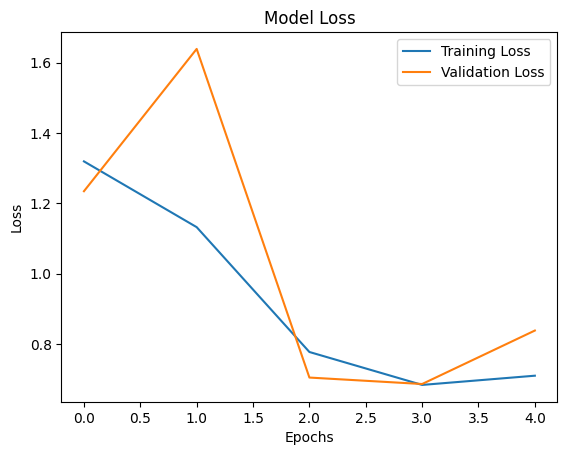

In [ ]:
print(History.history.keys())
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

In [ ]:
# list(test_dataset.as_numpy_iterator())

In [ ]:
test_dataset = test_dataset.batch(1) # Have to do this because we need to keep into account the dimension of the test dataset as well while evaluating.
lenet_model.evaluate(test_dataset)

# We have a 64.5% accuracy

1377/1377 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8744 - auc: 0.9574 - fn: 11.0000 - fp: 162.0000 - loss: 0.8343 - precision: 0.8060 - recall: 0.9839 - tn: 531.0000 - tp: 673.0000


[0.8343100547790527,
 673.0,
 162.0,
 531.0,
 11.0,
 0.8743645548820496,
 0.8059880137443542,
 0.9839181303977966,
 0.9574008584022522]

# Visualizing Confusion Matrix

In [ ]:
labels = []
inp = [] # input

for x,y in test_dataset.as_numpy_iterator():
    labels.append(y[0]) # we did y[0] to ge the number in the list which was like [array([1]), array([0])...]
    inp.append(x)

In [ ]:
# labels = np.array([i[0] for i in labels])
# print(labels)
# print(len(labels)) has this kind of a list - '[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0),'...]

In [ ]:
print(np.array(inp).shape)
print(np.array(inp)[:,0,...].shape) # Want to remove the 1st index dimension aka the '1', so we put a '0'. ':' is for selecting the 0th index, '0' is for not selecting the 1st index

In [ ]:
predicted = lenet_model.predict(np.array(inp)[:,0,...])

In [ ]:
print(predicted.shape)

# We want to make the predicted shape to be the same as the labels shape
print(f'Predicted Shape: {predicted[:,0].shape}')
print(f'Labels Shape: {len(labels)}')

print(predicted[:,0])

In [ ]:
# MAKING THE CONFUSION MATRIX
threshold = 0.5
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

cm = confusion_matrix(labels, predicted > threshold) # all values great than threshold is uninfected
print(cm)
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True,)
plt.title(f'Confusion matrix - {threshold}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# tn: 643.0000 - tp: 624.0000
# fn: 65.0000 - fp: 45.0000

We want a low number for the FALSE NEGATIVES(FN), so in this case we want a high 'RECALL'

# ROC Curve

In [ ]:
# We can use this to choose the best threshold.
# A point at the ROC plot is a threshold value for the TP rate and the FP rate.
# Y axis - Recall [TP/(TP + FN)]
# X axis - [FP/(FP+TN)]
# Overall GOAL - FP is MINIMIZED and TP is MAXIMIZED

In [ ]:
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

fp, tp, thresholds = roc_curve(labels, predicted)
plt.plot(fp, tp)
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.grid(color='gray', linestyle='--', linewidth=0.5)

skip =  50 # skip 50 values and then plot it

for i in range(0, len(thresholds), skip):
  plt.text(fp[i], tp[i], thresholds[i]) # to show the thresholds

plt.show()

In [ ]:
def parasite_or_not(x):
    if (x < 0.5):
        return 'P'
    else:
        return 'U'

In [ ]:
parasite_or_not(lenet_model.predict(test_dataset.take(1))[0][0]) 

'''# lenet_model.predict(test_dataset.take(1)) outputs:
[
  [0.85], # Image 0 prediction
  [0.12], # Image 1 prediction
  [0.44], # Image 2 prediction
  ...
  [0.91]  # Image 32 prediction
]
TensorFlow models output predictions in a 2D batch format [[0.85], [0.12]]. The first [0] selects the specific image in the batch, and the second [0] extracts the raw probability number 
from inside that vector.'''

In [ ]:
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_model.predict(image)[0][0])))
    plt.axis('off')

# Saving to and Loading from Google Drive

In [ ]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

In [ ]:
lenet_model.export('/content/drive/MyDrive/lenet_saved_directory')
drive_folder_path = '/content/drive/MyDrive/lenet_saved_directory'

# Load the directory as a specialized inference layer
lenet_loaded = tf.keras.layers.TFSMLayer(drive_folder_path, call_endpoint='serve')

print("Model loaded successfully from Google Drive!")

In [ ]:
lenet_model.save('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded = tf.keras.models.load_model('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded.summary()

In [ ]:
# Using the LOADED MODEL from google drive to do the predictions
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_loaded.predict(image)[0][0])))
    plt.axis('off')

In [ ]:
lenet_loaded.evaluate(test_dataset)

## Saving using the HDF5 method -> lightweight Model Saving Method

In [ ]:
# In a HDF5 format the configurations aren't stored, so you will have to compile the model again
lenet_model.save('/content/drive/MyDrive/lenet_malaria_model.h5')


In [ ]:
h5_model_path = '/content/drive/MyDrive/lenet_malaria_model.h5'
lenet_loaded_h5 = tf.keras.models.load_model(h5_model_path, compile=False) 
# If you only want to use the model for inference (making predictions) 
#and want to skip loading the optimizer, you can add compile=False to speed things up
# Setting compile=False tells Keras: "Just load the brain (weights and architecture). Do not waste time loading the training setup or rebuilding the optimizer."
lenet_loaded_h5.summary()

In [ ]:
# lenet_loaded_h5.evaluate(test_dataset) # In a HDF5 format the configurations aren't stored, so you will have to compile the model again

# ERROR GIVEN - You must call `compile()` before using the model.

## Saving Just the Weights given that we already have the model's configurations

In [ ]:
# lenet_model.save_weights("weights/lenet_weights.weights.h5")

In [ ]:
# lenet_weights_model = lenet_model.load_weights("weights/lenet_weights")